# **Deep Reinforcement Learning for Fano Hypersurfaces**

We design a deep reinforcement learning algorithm to explore a high-dimensional integer lattice with sparse rewards, training a feedforward neural network as a dynamic search heuristic to steer exploration toward reward dense regions. We apply this to the discovery of Fano $4$-fold hypersurfaces with terminal singularities, objects of central importance in algebraic geometry. Fano varieties with terminal singularities are fundamental building blocks of algebraic varieties, and explicit examples serve as a vital testing ground for the development and generalisation of theory. Despite decades of effort, the combinatorial intractability of the underlying search space has left this classification severely incomplete. Our reinforcement learning approach yields thousands of previously unknown examples, hundreds of which we show are inaccessible to known search methods.

The file is seperated into the following parts:

$\S0$ **Setup**: Define global constants, and load packages \
$\S1$ **Terminal**: Code to determine whether a point associated to a hypersurface is terminal or not \
$\S2$ **Fixed Heuristic**: Code performing the fixed heuristic search \
$\S3$ **Dynamic Heuristic**: Code performing the dynamic heuristic (deep reinforcement learning) search \
$\S4$ **Analysis**: We analyse the results of both searches

## $\S0$ Setup

In [ ]:
#Constants
dim_X = 4 #dimension of hypersurface
alpha_X = 1 #adjunction number of hypersurface
state_dim = dim_X + 2 #dimension of state space
action_dim = 1 #dimension of action space

In [ ]:
#Packages

#Terminal
import math as m
import itertools as it
import numpy as np

#Searches
import torch as th
import torch.nn as nn
import heapq as hq
import random as rd
import os
import pandas as pd
import json

#Figures
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import MaxNLocator
from labellines import labelLines

## $\S1$ Terminal

In [ ]:
#terminal_point(point): returns True if the point corresponds to a terminal hypersurface, False otherwise 
def terminal_point(point):
    degree = sum(point) - alpha_X
    if wellformedness(degree, point):
        if terminal_sufficient_condition(point):
            sings = terminal_singularities(degree, point)
            if sings !=False:
                return True
        return False
    
#wellformedness(degree, point): returns True if the point is well-formed, False otherwise (Fletcher criterion)
def wellformedness(degree, point): #Fletcher criterion
    #(1)
    for i,j in it.combinations(range(len(point)),2):
        if degree % m.gcd(*(point[k] for k in range(len(point)) if k != i if k != j)) != 0:
            return False
    #(2)
    for i in range(len(point)):
        if m.gcd(*(point[k] for k in range(len(point)) if k != i)) != 1:
            return False
    return True

#terminal_sufficient_condition(point): returns True if the point satisfies the sufficient condition for terminality, False otherwise
def terminal_sufficient_condition(point):
    d = sum(point) - alpha_X
    for a in point:
        if d % a != 0:
            for k in range(1, a):
                discrep_estimate = sum((k * w) % a for w in point) - (k* d) % a - a
                if discrep_estimate <= 0:
                    return False
    return True
    
#terminal_singularities(degree, point): returns list of terminal singularities if all singularities are terminal, False otherwise
def terminal_singularities(degree, point):
    sings = []
    point_strata = strata(point)
    for stratum in point_strata:
        h_I, stratum_weights, stratum_indices, k = stratum
        mu_I = mu(degree, stratum_weights)
        if mu_I == 1:
            continue
        elif mu_I >= 2:
            dim_qs = k - 1
            qsness = "qs"
            if h_I == 1:
                continue 
            else: #h_I >= 2
                sing_type = "quotient"
                t = tangent_index(degree, point, stratum_weights, stratum_indices)
                stratum_indices_without_t = tuple(i for i in stratum_indices if i != t)
                sing_weights = tuple(point[i] % h_I for i in range(len(point)) if i != stratum_indices_without_t[0] if i != t)
                sing = (h_I, sing_weights, stratum_weights, point[t], dim_qs, sing_type, qsness)
                if terminal(degree, point, sing, k):
                        sings.append(sing)
                else:
                    return False
        else: #mu_I == 0
            dim_qs = k
            rho_I = rho(degree, point, stratum_weights)
            stratum_indices_complement = tuple(i for i in range(len(point)) if i not in stratum_indices)
            nonqs_existence  = rank_test(degree, point, stratum_weights, stratum_indices_complement)
            if rho_I > k or nonqs_existence == False:
                qsness = "qs"
                if h_I == 1:
                    continue 
                else: #h_I >= 2
                    sing_type = "quotient"
                    t = tangent_index(degree, point, stratum_weights, stratum_indices_complement)
                    sing_weights = tuple(point[i] % h_I for i in range(len(point)) if i != stratum_indices[0] if i != t)
                    sing = (h_I, sing_weights, point[t], stratum_weights, dim_qs, sing_type, qsness)
                    if terminal(degree, point, sing, k):
                            sings.append(sing)
                    else:
                        return False
            else: #rho_I<=k and nonqs_existence == True
                if rho_I == 0:
                    qsness = "nonqs"
                    dim_nonqs = k
                    if h_I == 1:
                        sing_type = "hypersurface"
                        sing_weights = tuple(point[i] % h_I for i in range(len(point)) if i != stratum_indices[0])
                        e = degree % h_I
                        sing = (h_I, sing_weights, e, stratum_weights, dim_nonqs, sing_type, qsness)
                        if terminal(degree, point, sing, k):
                            sings.append(sing)
                        else:
                            return False
                    else: #h_I >= 2
                        sing_type = "hyperquotient"
                        sing_weights = tuple(point[i] % h_I for i in range(len(point)) if i != stratum_indices[0])
                        e = degree % h_I
                        sing = (h_I, sing_weights, e, stratum_weights, dim_nonqs, sing_type, qsness)
                        if terminal(degree, point, sing, k):
                            sings.append(sing)
                        else:
                            return False
                else: #1<=rho_I<= k
                    dim_nonqs = k - rho_I
                    if h_I == 1:
                        qsness= "nonqs"
                        sing_type = "hypersurface"
                        sing_weights = tuple(point[i] % h_I for i in range(len(point)) if i != stratum_indices[0])
                        e = degree % h_I
                        sing = (h_I, sing_weights, e, stratum_weights, dim_nonqs, sing_type, qsness)
                        if terminal(degree, point, sing, k):
                            sings.append(sing)
                        else:
                            return False
                    else: #h_I >= 2
                        qsness= "qs"
                        sing_type = "quotient"
                        t = tangent_index(degree, point, stratum_weights, stratum_indices_complement) 
                        sing_weights = tuple(point[i] % h_I for i in range(len(point)) if i != stratum_indices[0] if i != t)
                        sing = (h_I, sing_weights, point[t], stratum_weights, dim_qs, sing_type, qsness)
                        if terminal(degree, point, sing, k):
                            sings.append(sing)
                        else:
                            return False
                        qsness= "nonqs"
                        sing_type = "hyperquotient"
                        sing_weights = tuple(point[i] % h_I for i in range(len(point)) if i != stratum_indices[0])
                        e = degree % h_I
                        sing = (h_I, sing_weights, e, stratum_weights, dim_nonqs, sing_type, qsness)
                        if terminal(degree, point, sing, k):
                            sings.append(sing)
                        else:
                            return False
    return sings

#strata(point): returns list of strata, where each stratum is given by (h_I, stratum_weights, stratum_indices, k)
#h_I is the gcd of the stratum weights, k is the dimension of the stratum
def strata(point):
    strata = []
    for stratum_len in range(1, len(point) + 1):
        for stratum_indices in it.combinations(range(len(point)), stratum_len):
            stratum_weights = tuple(point[i] for i in stratum_indices)
            h_I = m.gcd(*stratum_weights)
            k = len(stratum_weights) - 1
            stratum = (h_I, stratum_weights, stratum_indices, k)
            strata.append(stratum)
    return tuple(strata)

#monomial_exists(degree, stratum_weights): returns True if there exists a monomial of the given degree that can be formed using the stratum weights, False otherwise
def monomial_exists(degree, stratum_weights):
    def monomial_builder_recursive(total,index):
        if index == len(stratum_weights):
            return total == degree
        for m in range((degree - total) // stratum_weights[index] + 1):
            if monomial_builder_recursive(total + m * stratum_weights[index], index + 1):
                return True
        return False
    return monomial_builder_recursive(0, 0)

#tangent_index(degree, point, stratum_weights, search_indices): returns the index of a tangent variable if it exists, None otherwise
def tangent_index(degree, point, stratum_weights, search_indices):
    for i in search_indices:
        if monomial_exists(degree - point[i], stratum_weights):
            return i
    return None

#mu(degree, stratum_weights): returns the number of monomials of the given degree that can be formed using the stratum weights
def mu(degree, stratum_weights):
    combinations = [0] * (degree + 1) # combinations[i] = number of ways to make i from stratum_weights
    combinations[0] = 1 
    for w in stratum_weights:
        for i in range(w, degree + 1): 
            combinations[i] += combinations[i - w]
        if combinations[degree] >= 2:
            return 2
    return combinations[degree]

#rho(degree, point, stratum_weights): returns the number of tangent variables
def rho(degree, point, stratum_weights):
    rho_count = 0
    for a_t in point:
        if mu(degree - a_t, stratum_weights) >= 1:
            rho_count += 1
    return rho_count

#monomial_finder(degree, stratum_weights, monomial_blacklist): returns a monomial of the given degree that can be formed using the stratum weights and is not in the monomial blacklist, None if no such monomial exists
def monomial_finder(degree, stratum_weights, monomial_blacklist):
    n = len(stratum_weights)
    def monomial_builder_recursive(index, monomial):
        total = sum(monomial[i] * stratum_weights[i] for i in range(n))
        if index == n:
            return monomial if (total == degree) and (monomial not in monomial_blacklist) else None
        for m in range((degree - total) // stratum_weights[index] + 1):
            new_monomial = tuple(monomial[i] if i != index else m for i in range(n))
            result = monomial_builder_recursive(index + 1, new_monomial)
            if result is not None:
                return result
        return None
    return monomial_builder_recursive(0, (0,) * n)

#rank_test(degree, point, stratum_weights, search_indices): returns True if the rank condition is satisfied, False otherwise
def rank_test(degree, point, stratum_weights, search_indices): 
    J = []
    unsearched_indices = search_indices
    for i in search_indices:
        t = tangent_index(degree, point, stratum_weights, unsearched_indices)
        if t != None:
            unsearched_indices = tuple(i for i in unsearched_indices if i != t)
            J.append(t)
    #len(J)=0 case automatically wins
    if len(J) == 0:
        return True 
    #l==1 case can be simplified
    for j in J:
        if mu(degree - point[j], stratum_weights) == 1:
            return False
    #l>=2 case
    monomials_J = [[] for _ in range(len(point))]
    def grab_new_monomial(I):
        for i in I:
            monomial = monomial_finder(degree - point[i], stratum_weights, monomials_J[i]) 
            if monomial != None: 
                monomials_J[i].append(monomial)
                return True
        return False
    grab_available = True
    for l in range (2, len(J) + 1): #can maybe optimise here than finding all monomials!
        for I in it.combinations(J, l):
            criterion_not_met = True
            #print(point, stratum_weights, J, I, monomials_J)
            while criterion_not_met:
                if grab_available == True:
                    grab_available = grab_new_monomial(J)
                matrix_entries = [monomials_J[j][i] for j in I for i in range(len(monomials_J[j]))]
                matrix_entries_shifted_to_origin = [list(np.array(m) - np.array(matrix_entries[0])) for m in matrix_entries]
                matrix = np.array(matrix_entries_shifted_to_origin)
                rank = np.linalg.matrix_rank(matrix)
                if rank >= l:
                    break
                if grab_available == False: #means all monomials in play and didnt satisfy criterion, so fail
                    return False
    return True

#terminal(degree, point, sing, stratum): returns True if the given singularity is terminal, False otherwise
def terminal(degree, point, sing, k):
    if k > dim_X - 2:
        return False
    r = sing[0]
    sing_weights = sing[1]
    qsness = sing[-1]
    if qsness == "qs": #quasismooth
        #Apply Reid--Shepherd-Barron--Tai criterion
        for i in range(1, r):
            alpha_sum = sum((i * weight) % r for weight in sing_weights)
            if alpha_sum - r <= 0:
                return False
        return True
    else: #nonquasismooth
        if r == 1:
            return True #An approximation
        else: #r>1
            #Apply Mori's criterion for the unit cube (a neccessary condition for terminality)
            def Mori_criterion(total, index, alpha_f):
                if index == len(alpha):
                    if total == degree and alpha_sum - alpha_f - r > 0:
                        return True
                    return False
                for m in range((degree - total) // point[index] + 1):
                    if Mori_criterion(total + m * point[index], index + 1, alpha_f + m * alpha[index]):
                        return True
                return False
            for i in range(1, r):
                alpha = tuple((i * weight) % r for weight in point)
                alpha_sum = sum((i * weight) % r for weight in sing_weights)
                if Mori_criterion(0, 0, 0) == False:
                    return False
            return True

## $\S2$ Fixed Heuristic

Environment and Agent

In [ ]:
#IntegerLattice: defines the environment, which is an integer lattice where each point corresponds to a hypersurface. 
#The agent starts at a given point and can move to neighbouring points by adding or subtracting 1 from one of the coordinates. 
#The environment keeps track of which points have been searched, which points are in the priority queue, and how many reward points have been found.

class IntegerLattice:
    
    #_init__(agent, dim, start_points): initialises the environment
    def __init__(self, agent, dim, start_points):
        self.dim = dim
        self.start_points = start_points
        self.step_count = 0
        self.reward_count = 0
        self.priority_queue = PriorityQueue()
        self.searched_points = set()
        self.queued_points = set()
        for point in start_points:
            self.priority_queue.push(point, 2) #Initial priority value of 2 to ensure searched
            self.queued_points.add(point)
            self.reward_point(point, agent)
        self.reward_count = 0
        agent.reward_count = 0 

    #bounds(point): returns True if the point is in the positive quadrant and satisfies the ordering 1<= a_1 <= a_2 <= ... <= a_n, False otherwise
    def bounds(self, point):
        if all(a >= 1 for a in point):
            if all(point[i] <= point[i+1] for i in range(self.dim -1)):
                return True
        return False
    
    #find_neighbours(point): returns list of neighbouring points that satisfy the bounds
    def find_neighbours(self, point):
        neighbours = []
        for i in range(self.dim):
            for delta in [-1,1]:
                n = list(point)
                n[i] += delta
                n = tuple(n)
                if self.bounds(n):
                    neighbours.append(n)
        return neighbours
    
    #reward_point(point, agent): returns True if the point is a reward point and updates the agent's reward count and reward points set, False otherwise
    def reward_point(self, point, agent):
        if terminal_point(point):
            if point not in agent.reward_points:
                agent.reward_count += 1
                agent.reward_points.add(point)
            return True
        else:
            return False

    #priority_function(priority_point, is_reward): returns the priority value for a point based on whether it is a reward point or not.
    def priority_function(self, priority_point, is_reward):
        if is_reward:
            return 1
        else:
            return priority_point/2

    #step(agent): peforms a step in the environment
    def step(self, agent):
        self.step_count += 1 
        agent.step_count += 1
        point, priority_point = self.priority_queue.pop()
        self.searched_points.add(point)
        neighbours = self.find_neighbours(point)
        for n in neighbours:
            if n not in self.queued_points:
                is_reward = self.reward_point(n, agent)
                v = self.priority_function(priority_point, is_reward)
                self.priority_queue.push(n, v)
                self.queued_points.add(n)

#Agent: defines the agent, which both keeps track of data and interacts with the environment by taking steps and receiving rewards.
class Agent:

    #_init__(): initialises the agent
    def __init__(self):
        self.step_count = 0
        self.reward_points = set() 
        self.reward_count = 0
        self.data_reward_vs_steps = [(0, 0)]

    #record_reward_vs_steps(): records the current reward count and step count in the data collection for reward vs steps.
    def record_reward_vs_steps(self):
        self.data_reward_vs_steps.append((self.step_count, self.reward_count))

#PriorityQueue: defines a priority queue using a heap, where points are stored with their priority values.
class PriorityQueue:

    #_init__(): initializes the priority queue with an empty heap
    def __init__(self):
        self.heap = []
    
    #push(point, priority): pushes a point with the given priority value onto the heap
    def push(self, point, priority):
        hq.heappush(self.heap, (-priority, point))
    
    #pop(): pops the point with the highest priority value from the heap and returns it along with its priority value
    def pop(self):
        neg_priority_point, search_point = hq.heappop(self.heap)
        return search_point, -neg_priority_point


Run Search

In [ ]:
#Search variables
qs = pd.read_csv("data/qs_terminal.csv", header=None).values.astype(int).tolist()
qs = [tuple(point[1:]) for point in qs]
start_points = qs
max_steps = 10_000_000

#Instantiate the agent and environment
agent = Agent()
env = IntegerLattice(agent, state_dim, start_points)

#main(agent, env): runs the main loop of the environment, where the agent takes steps and records data at regular intervals.
def main(agent, env):
    for s in range(1, max_steps + 1):
        env.step(agent)
        if s % 100 == 0:
            agent.record_reward_vs_steps()
        if s % 1000 == 0:
            print("Step:", s, ", Terminal:", agent.reward_count, "Visited:", len(env.searched_points))

main(agent, env)

Save Data

In [ ]:
dim_X = 4 #dimension of hypersurface
alpha_X = 1 #adjunction number of hypersurface

state_dim = dim_X + 2 #dimension of state space
action_dim = 1 #dimension of action space

In [ ]:
fixed_settings = {"max_steps": max_steps, "dim_X": dim_X, "alpha_X": alpha_X, "state_dim": state_dim, "action_dim": action_dim}
fixed_qs_start_terminal_points = list(agent.reward_points)
fixed_qs_start_searched_points = list(env.searched_points)
fixed_qs_start_reward_vs_steps = agent.data_reward_vs_steps

#Create data directory if it doesn't exist
os.makedirs("data", exist_ok=True)

#Store data to files
with open("data/fixed_settings.json", "w") as f:
    json.dump(fixed_settings, f, indent=4)
np.savetxt(f"data/fixed_terminal_points.csv", fixed_qs_start_terminal_points, delimiter=",")
np.savetxt(f"data/fixed_searched_points.csv", fixed_qs_start_searched_points, delimiter=",")
np.savetxt(f"data/fixed_reward_vs_steps.csv", fixed_qs_start_reward_vs_steps, delimiter=",")

## $\S3$ Dynamic Heuristic (Deep Reinforcement Learning)

Environment and Agent

In [ ]:
#IntegerLattice: defines the environment, which is an integer lattice where each point corresponds to a hypersurface. 
#The agent starts at a given point and can move to neighbouring points by adding or subtracting 1 from one of the coordinates. 
#The environment keeps track of which points have been searched, which points are in the priority queue, and how many reward points have been found.

class IntegerLattice:

    #_init__(agent, dim, start_points, reward_value, sigma): initialises the environment
    def __init__(self, agent, dim, start_points, reward_value, sigma):
        self.dim = dim
        self.start_points = start_points
        self.reward_value = reward_value
        self.sigma = sigma
        self.step_episode = 1
        self.step_count = 0
        self.steps_since_reward = 0
        self.priority_queue = PriorityQueue()
        self.searched_points = set()
        self.queued_points = set()
        for point in start_points:
            self.priority_queue.push(point, self.reward_value*1000) #Initial priority value of reward_value*1000 to ensure searched
            self.queued_points.add(point)
            self.reward_point(point, agent)
        agent.reward_count = 0 

    #reset(): resets the environment for a new episode
    def reset(self):
        self.step_episode += 1
        self.step_count = 0
        self.priority_queue = PriorityQueue()
        self.searched_points = set()
        self.queued_points = set()
        for point in self.start_points:
            self.priority_queue.push(point, self.reward_value*1000)
            self.queued_points.add(point)

    #bounds(point): returns True if the point is in the positive quadrant and satisfies the ordering 1<= a_1 <= a_2 <= ... <= a_n, False otherwise
    def bounds(self, point):
        if all(a >= 1 for a in point): 
            if all(point[i] <= point[i+1] for i in range(self.dim -1)):
                return True
        return False
    
    #find_neighbours(point): returns list of neighbouring points that satisfy the bounds
    def find_neighbours(self, point):
        neighbours = []
        for i in range(self.dim):
            for delta in [-1,1]:
                n = list(point)
                n[i] += delta
                n = tuple(n)
                if self.bounds(n):
                    neighbours.append(n)
        return neighbours
    
    #reward_point(point, agent): returns True if the point is a reward point and updates the agent's reward count and reward points set, False otherwise
    def reward_point(self, point, agent):
        if (point in agent.reward_points):
            if point not in agent.reward_points_per_episode:
                agent.reward_points_per_episode.add(point)
            return True
        elif (point not in agent.nonreward_points and terminal_point(point)):
            if point not in agent.reward_points_per_episode:
                agent.reward_count += 1
                agent.reward_points.add(point)
                agent.reward_points_per_episode.add(point)
            return True
        else:
            if self.step_episode == 1: #Otherwise nonreward set gets too big for memory
                agent.nonreward_points.add(point)
            return False

    #reward_function(is_reward): returns the reward value for a point based on whether it is a reward point or not, and how many steps since the last reward.
    def reward_function(self, is_reward):
        if is_reward:
            return self.reward_value
        else:
            return -m.sqrt(self.steps_since_reward)

    #step(agent): peforms a step in the environment
    def step(self, agent):
        self.step_count += 1 
        agent.step_count += 1
        self.steps_since_reward += 1
        point = self.priority_queue.pop()
        self.searched_points.add(point)
        neighbours = self.find_neighbours(point)
        neighbours_tensor = th.tensor(neighbours, dtype=th.float32)
        reward_neighbours = []
        for n in neighbours:
            is_reward = self.reward_point(n, agent)
            reward_neighbours.append(is_reward)
        if any(reward_neighbours):
            self.steps_since_reward = 0
        batch = []
        for n, is_reward in zip(neighbours, reward_neighbours):
            reward = self.reward_function(is_reward)
            transition = (point, n, reward)
            batch.append(transition)
        agent.TD_training(batch)
        with th.no_grad():
            priority_values = agent.model(neighbours_tensor).numpy()
        for n, v in zip(neighbours, priority_values):
            if n not in self.queued_points:
                v = v + rd.gauss(0, self.sigma)
                self.priority_queue.push(n, v)
                self.queued_points.add(n)

#Agent: defines the agent, which both keeps track of data and interacts with the environment by taking steps and receiving rewards.
class Agent:

    #_init__(): initialises the agent with a neural network model, optimiser, loss function, and data collection attributes.
    def __init__(self, state_dim, action_dim, hidden_dims, gamma):
        self.model = NeuralNetwork(state_dim, action_dim, hidden_dims)
        self.gamma = gamma
        self.optimiser = th.optim.Adam(self.model.parameters(), lr=0.01)
        self.loss_function = nn.MSELoss()
        self.step_count = 0
        self.reward_points = set() 
        self.nonreward_points = set() 
        self.reward_count = 0
        self.reward_points_per_episode = set()
        self.data_reward_vs_steps = [[(0, 0)]]
        self.data_searched_points = []
        self.data_reward_points = []

    #reset(env): resets the agent's data collection and the environment for a new episode
    def reset(self, env):
        self.data_reward_vs_steps.append([(0, self.reward_count)])
        self.data_searched_points.append(list(env.searched_points))
        self.data_reward_points.append(list(self.reward_points_per_episode))
        self.reward_points_per_episode = set()
        self.step_count = 0
        env.reset()
    
    #TD_training(batch): performs a training step using temporal difference learning on a batch of transitions, where each transition is given by (point, neighbour, reward).
    def TD_training(self, batch):
            points, neighbours, rewards = zip(*batch)
            points_tensor = th.tensor(points, dtype=th.float32)
            neighbours_tensor = th.tensor(neighbours, dtype=th.float32)
            rewards_tensor = th.tensor(rewards, dtype=th.float32)
            with th.no_grad(): #fixed TD target
                target_values = rewards_tensor + self.gamma * self.model(neighbours_tensor)
            current_values = self.model(points_tensor)
            loss = self.loss_function(current_values, target_values)
            self.optimiser.zero_grad()
            loss.backward()
            self.optimiser.step()

    #record_reward_vs_steps(): records the current reward count and step count in the data collection for reward vs steps.
    def record_reward_vs_steps(self):
        self.data_reward_vs_steps[-1].append((self.step_count, self.reward_count))

#NeuralNetwork: defines a neural network model with an input layer, hidden layers, and an output layer, as well as an activation function. The forward method defines how data flows through the network.
class NeuralNetwork(nn.Module):

    #_init__(state_dim, action_dim, hidden_dims): initializes the neural network with the given state dimension, action dimension, and hidden layer dimensions. It sets up the layers and activation function.
    def __init__(self, state_dim, action_dim, hidden_dims):
        super().__init__()
        self.input_layer = nn.Linear(state_dim, hidden_dims[0])
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dims[i], hidden_dims[i + 1]) for i in range(len(hidden_dims) - 1)])
        self.output_layer = nn.Linear(hidden_dims[-1], action_dim)
        self.activation = nn.LeakyReLU(negative_slope=0.01)
    
    #forward(x): defines the forward pass of the neural network, where input x is passed through the input layer, hidden layers with activation, and output layer to produce the output value.
    def forward(self, x):
        x = self.activation(self.input_layer(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        return self.output_layer(x).squeeze(-1)

#PriorityQueue: defines a priority queue using a heap, where points are stored with their priority values.
class PriorityQueue:

    #_init__(): initializes the priority queue with an empty heap
    def __init__(self):
        self.heap = []
    
    #push(point, priority): pushes a point with the given priority value onto the heap
    def push(self, point, priority):
        hq.heappush(self.heap, (-priority, point))
    
    #pop(): pops the point with the highest priority value from the heap and returns it along with its priority value
    def pop(self):
        search_point = hq.heappop(self.heap)[1]
        return search_point


Run Search

In [ ]:
#Hyperparameters
hidden_dims = (40,)
gamma = 0.2
reward_value = 1
sigma = 2

#Search variables
qs = pd.read_csv("data/qs_terminal.csv", header=None).values.astype(int).tolist()
qs = [tuple(point[1:]) for point in qs]
start_points = qs
max_steps = 10_000_000
max_episodes = 1

#Instantiate the agent and environment
agent = Agent(state_dim, action_dim, hidden_dims, gamma)
env = IntegerLattice(agent, state_dim, start_points, reward_value, sigma)

#main(agent, env): runs the main loop of the environment, where the agent takes steps and records data at regular intervals. At the end of each episode, the agent and environment are reset.
def main(agent, env):
    for ep in range(1, max_episodes + 1):
        for s in range(1, max_steps + 1):
            env.step(agent)
            if s % 100 == 0:
                agent.record_reward_vs_steps()
            if s % 1000 == 0:
                print("Episode: ", ep, ", Step:", s, ", Terminal:", agent.reward_count, ", Nonreward:", len(agent.nonreward_points), ", Visited:", len(env.searched_points))
        agent.reset(env)

main(agent, env)

Save Data

In [ ]:
dynamic_settings = {"hidden_dims": hidden_dims, "gamma": gamma, "reward_value": reward_value, "sigma": sigma, "max_steps": max_steps, "max_episodes": max_episodes, "dim_X": dim_X, "alpha_X": alpha_X, "state_dim": state_dim, "action_dim": action_dim}
dynamic_terminal_points_total = list(agent.reward_points)
dynamic_searched_points_episodal = list(agent.data_searched_points)
dynamic_reward_vs_steps_episodal = agent.data_reward_vs_steps
dynamic_nonterminal_points_total = list(agent.nonreward_points)

#Create data directory if it doesn't exist
os.makedirs("data", exist_ok=True)

#Store data to files
with open("data/dynamic_settings.json", "w") as f:
    json.dump(dynamic_settings, f, indent=4)
np.savetxt("data/dynamic_terminal_points_total.csv", dynamic_terminal_points_total, delimiter=",")
for i in range(1, len(dynamic_searched_points_episodal) + 1):
    np.savetxt(f"data/dynamic_searched_points_episode_{i}.csv", dynamic_searched_points_episodal[i-1], delimiter=",")
    np.savetxt(f"data/dynamic_reward_vs_steps_episode_{i}.csv", dynamic_reward_vs_steps_episodal[i-1], delimiter=",")
th.save(agent.model.state_dict(), "data/dynamic_qs_start_model.pth")
np.savetxt("data/dynamic_nonterminal_points_total.csv", dynamic_nonterminal_points_total, delimiter=",")

## $\S4$ Analysis

Load Data

In [ ]:
#Fixed Heuristic Search Data
fixed_settings = json.load(open("data/fixed_settings.json"))
fixed_terminal_points = pd.read_csv(f"data/fixed_terminal_points.csv", header=None).values
fixed_searched_points = pd.read_csv(f"data/fixed_searched_points.csv", header=None).values
fixed_reward_vs_steps = pd.read_csv(f"data/fixed_reward_vs_steps.csv", header=None).values

#Dynamic Heuristic Search Data
dynamic_settings = json.load(open("data/dynamic_settings.json"))
max_episodes = dynamic_settings["max_episodes"]
state_dim = dynamic_settings["state_dim"]
dynamic_terminal_points_total = pd.read_csv(f"data/dynamic_terminal_points_total.csv", header=None).values
dynamic_terminal_points_episodal = []
dynamic_searched_points_episodal = []
dynamic_reward_vs_steps_episodal = []
for i in range(1, max_episodes + 1):
    dynamic_terminal_points_episodal.append(pd.read_csv(f"data/dynamic_terminal_points_episode_{i}.csv", header=None).values)
    dynamic_searched_points_episodal.append(pd.read_csv(f"data/dynamic_searched_points_episode_{i}.csv", header=None).values)
    dynamic_reward_vs_steps_episodal.append(pd.read_csv(f"data/dynamic_reward_vs_steps_episode_{i}.csv", header=None).values)
#dynamic_qs_start_model = agent.model.load_state_dict(th.load("data/dynamic_qs_start_model.pth"))

Reward vs Steps

In [ ]:
#Font settings
plt.rcParams.update({
    "text.usetex": False,       
    "font.family": "serif",     
    "font.serif": ["DejaVu Serif"],  
    "mathtext.fontset": "cm",  
})

#Instantiate plot
fig, ax = plt.subplots(figsize=(7, 6))
lines = []
xvals = []

#Fixed heuristic
fixed_steps = fixed_reward_vs_steps[:, 0]
fixed_rewards = fixed_reward_vs_steps[:, 1]
line = ax.plot(fixed_steps, fixed_rewards, color='blue', alpha=0.5, linewidth=2,linestyle='--', label='Fixed Heuristic')
lines.append(line)
xvals.append(fixed_steps[-1]*0.75)

#Dynamic heuristic
for i in range(max_episodes):
    dynamic_reward_vs_steps_episode = dynamic_reward_vs_steps_episodal[i]
    dynamic_steps = dynamic_reward_vs_steps_episode[:, 0]
    dynamic_rewards = dynamic_reward_vs_steps_episode[:, 1]
    line = ax.plot(dynamic_steps, dynamic_rewards, color='blue', alpha=0.5, linewidth=2, label=f'Dynamic Heuristic')
    lines.append(line)
    xvals.append(dynamic_steps[-1]*0.75)

#Format plot
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.grid(axis="y", alpha=0.3, linestyle='-')
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines['bottom'].set_color("grey")
ax.tick_params(axis='x', colors="grey")
ax.xaxis.label.set_color("grey")
ax.yaxis.label.set_color("grey")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.yaxis.set_tick_params(width=0)
plt.xticks(rotation=45)
plt.xticks(fontsize=18, color='grey')
plt.yticks(fontsize=18, color='grey')

#Labels and legend
ax.set_xlabel(f"Step Count", fontsize=20, color='grey', labelpad = 15)
ax.set_ylabel(f"Terminal Points Found", fontsize=20, color='grey', labelpad= 15)
plt.legend(frameon=False, fontsize=18, loc='lower right', title = r"$\mathbf{Searches}$", title_fontsize=20)
lines = ax.get_lines()
#labels_for_lines = [f"Fix."]+[f"Dyn.{i}" for i in range(1, max_episodes + 1)] #If you want episode-wise labels instead of a single dynamic heuristic label
labels_for_lines = [f"Fix."]+[f"Dyn."]
for line, label in zip(lines, labels_for_lines):
    line.set_label(label)
labelLines(lines, xvals=xvals, align=True, fontsize=18)


plt.show()

#Create data directory if it doesn't exist
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/rewards_vs_steps.png", dpi=600, bbox_inches="tight")


Fixed Search

In [ ]:
#Seperate quasismooth and nonquasismooth terminal points for plotting
fixed_terminal_points_qs = []
fixed_terminal_points_nonqs = []
qs = pd.read_csv("data/qs_terminal.csv", header=None).values.astype(int).tolist()
qs = [tuple(point[1:]) for point in qs]
for point in fixed_terminal_points:
    if tuple(point) in qs:
         fixed_terminal_points_qs.append(tuple(point))
    else:
        fixed_terminal_points_nonqs.append(tuple(point))

#Font settings
plt.rcParams.update({
    "text.usetex": False,       # don't require external LaTeX
    "font.family": "serif",     # generic family (will map automatically)
    "font.serif": ["DejaVu Serif"],  # built-in, always available
    "mathtext.fontset": "cm",   # use Computer Modern for math text
})

#Instantiate plot
fig, axs = plt.subplots(2, 3 , figsize=(30,20))
axs = axs.flatten()

#Project the data via (a1,...,an) -> (ai+1, ai+2) for i=0,...,n-2
for i in range(state_dim - 1):
    ax = axs[i]
    i1 = i
    i2 = i + 1

    #Determine grid size
    max_value = int(max(
        max(point[i1] for point in fixed_searched_points),
        max(point[i2] for point in fixed_searched_points),
    ))

    #Grid points
    X, Y = np.meshgrid(range(1, max_value + 1), range(1, max_value + 1))
    X = X.flatten()
    Y = Y.flatten()

    #Marker size
    ax_width = ax.get_window_extent().width
    ax_height = ax.get_window_extent().height
    marker_size = (min(ax_width/ max_value, ax_height/ max_value) * 0.85) ** 2 

    #Grey points where ai<=aj
    grey_mask = X <= Y
    ax.scatter(X[grey_mask], Y[grey_mask], color='#eeeee4', s=marker_size, alpha=1, label='Searchable')

    #Searched points
    ax_ay_searched = list(set([(point[i1],point[i2]) for point in fixed_searched_points]))
    ax.scatter(*zip(*ax_ay_searched), color='orange', s=marker_size, alpha=1, label='Searched')

    #Quasismooth terminal points
    ax_ay_terminal = list(set([(point[i1],point[i2]) for point in fixed_terminal_points_qs]))
    ax.scatter(*zip(*ax_ay_terminal), color='black', s=marker_size, alpha=1, label='Quasismooth terminal')

    #Nonquasismooth terminal points
    ax_ay_terminal = list(set([(point[i1],point[i2]) for point in fixed_terminal_points_nonqs]))
    ax.scatter(*zip(*ax_ay_terminal), color='blue', s=marker_size, alpha=0.5, label='Nonquasismooth terminal')

    #Lablels and title
    ax.set_xlabel(f'$a_{i1+1}$', fontsize=40, color='grey')
    ax.set_ylabel(f'$a_{i2+1}$', fontsize=40, color='grey')

    #Format plot
    num_bins = 6
    ticks = list(np.linspace(0, max_value, num_bins))
    ticks.append(1)
    ticks = sorted(set(ticks))
    ticks = [int(t) for t in ticks if t != 0]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(axis='both', which='both', length=0, labelsize=20, colors="grey")

axs[state_dim - 1].axis('off')

#Legend
h, l = ax.get_legend_handles_labels()
axs[state_dim - 1].legend(
    h, l,
    frameon=False,
    markerscale=100,
    loc='center',
    fontsize=40,
    title=r'$\mathbf{Point\ Types}$',
    title_fontsize=45
)

plt.tight_layout()
plt.show()

#Create data directory if it doesn't exist
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/search_fixed.png", dpi=600, bbox_inches="tight")



Dynamic

In [ ]:
#Seperate quasismooth and nonquasismooth terminal points for plotting
dynamic_terminal_points_qs = []
dynamic_terminal_points_nonqs = []
qs = pd.read_csv("data/qs_terminal.csv", header=None).values.astype(int).tolist()
qs = [tuple(point[1:]) for point in qs]
for point in dynamic_terminal_points_total:
    if tuple(point) in qs:
         dynamic_terminal_points_qs.append(tuple(point))
    else:
        dynamic_terminal_points_nonqs.append(tuple(point))

#Combine searched points from all episodes for plotting
dynamic_searched_points = []
for i in range(max_episodes):
    for point in dynamic_searched_points_episodal[i]:
        dynamic_searched_points.append(tuple(point))

#Font settings
plt.rcParams.update({
    "text.usetex": False,       # don't require external LaTeX
    "font.family": "serif",     # generic family (will map automatically)
    "font.serif": ["DejaVu Serif"],  # built-in, always available
    "mathtext.fontset": "cm",   # use Computer Modern for math text
})

#Instantiate plot
fig, axs = plt.subplots(2, 3 , figsize=(30,20))
axs = axs.flatten()

#Project the data via (a1,...,an) -> (ai+1, ai+2) for i=0,...,n-2
for i in range(state_dim - 1):
    ax = axs[i]
    i1 = i
    i2 = i + 1

    #Determine grid size
    max_value = int(max(
        max(point[i1] for point in dynamic_searched_points),
        max(point[i2] for point in dynamic_searched_points),
    ))

    #Grid points
    X, Y = np.meshgrid(range(1, max_value + 1), range(1, max_value + 1))
    X = X.flatten()
    Y = Y.flatten()

    #Marker size
    ax_width = ax.get_window_extent().width
    ax_height = ax.get_window_extent().height
    marker_size = (min(ax_width/ max_value, ax_height/ max_value) * 0.85) ** 2 

    #Grey points where ai<=aj
    grey_mask = X <= Y
    ax.scatter(X[grey_mask], Y[grey_mask], color='#eeeee4', s=marker_size, alpha=1, label='Searchable')

    #Searched points
    ax_ay_searched = list(set([(point[i1],point[i2]) for point in dynamic_searched_points]))
    ax.scatter(*zip(*ax_ay_searched), color='orange', s=marker_size, alpha=1, label='Searched')

    #Quasismooth terminal points
    ax_ay_terminal = list(set([(point[i1],point[i2]) for point in dynamic_terminal_points_qs]))
    ax.scatter(*zip(*ax_ay_terminal), color='black', s=marker_size, alpha=1, label='Quasismooth terminal')

    #Nonquasismooth terminal points
    ax_ay_terminal = list(set([(point[i1],point[i2]) for point in dynamic_terminal_points_nonqs]))
    ax.scatter(*zip(*ax_ay_terminal), color='blue', s=marker_size, alpha=0.5, label='Nonquasismooth terminal')

    #Lablels and title
    ax.set_xlabel(f'$a_{i1+1}$', fontsize=40, color='grey')
    ax.set_ylabel(f'$a_{i2+1}$', fontsize=40, color='grey')

    #Format plot
    num_bins = 6
    ticks = list(np.linspace(0, max_value, num_bins))
    ticks.append(1)
    ticks = sorted(set(ticks))
    ticks = [int(t) for t in ticks if t != 0]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.tick_params(axis='both', which='both', length=0, labelsize=20, colors="grey")

axs[state_dim - 1].axis('off')

#Legend
h, l = ax.get_legend_handles_labels()
axs[state_dim - 1].legend(
    h, l,
    frameon=False,
    markerscale=100,
    loc='center',
    fontsize=40,
    title=r'$\mathbf{Point\ Types}$',
    title_fontsize=45
)

plt.tight_layout()
plt.show()

#Create data directory if it doesn't exist
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/search_dynamic.png", dpi=600, bbox_inches="tight")

Dynamic Search Hero 

In [ ]:
#Font settings
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",     
    "font.serif": ["DejaVu Serif"],  
    "mathtext.fontset": "cm",   
})

#Instantiate plot
fig, ax = plt.subplots(figsize=(20,20))

#Pick which coordinates to project onto (here we choose (a5, a6))
i = 4
i1 = i
i2 = i + 1

#Determine grid size
max_value = int(max(
    max(point[i1] for point in dynamic_searched_points),
    max(point[i2] for point in dynamic_searched_points)
))

#Grid points
X, Y = np.meshgrid(range(1, max_value + 1), range(1, max_value + 1))
X = X.flatten()
Y = Y.flatten()

#Dynamic marker size
ax_width = ax.get_window_extent().width
ax_height = ax.get_window_extent().height
marker_size = (min(ax_width/ max_value, ax_height/ max_value) * 0.85) ** 2 

#Grey points where ai<=aj
grey_mask = X <= Y
ax.scatter(X[grey_mask], Y[grey_mask], color='#eeeee4', s=marker_size, alpha=1, label='Searchable')

#Searched points
ax_ay_searched = list(set([(point[i1],point[i2]) for point in dynamic_searched_points]))
ax.scatter(*zip(*ax_ay_searched), color='orange', s=marker_size, alpha=1, label='Searched')

#Quasismooth terminal points
ax_ay_terminal = list(set([(point[i1],point[i2]) for point in dynamic_terminal_points_qs]))
ax.scatter(*zip(*ax_ay_terminal), color='black', s=marker_size, alpha=1, label='Quasismooth terminal (known)')

#Nonquasismooth terminal points
ax_ay_terminal = list(set([(point[i1],point[i2]) for point in dynamic_terminal_points_nonqs]))
ax.scatter(*zip(*ax_ay_terminal), color='blue', s=marker_size, alpha=0.5, label='Nonquasismooth terminal (new)')

#Lablels and title
ax.set_xlabel(f'$a_{i1+1}$', fontsize=40, color='grey')
ax.set_ylabel(f'$a_{i2+1}$', fontsize=40, color='grey')

#Format plot
num_bins = 6
ticks = list(np.linspace(0, max_value, num_bins))
ticks.append(1)
ticks = sorted(set(ticks))
ticks = [int(t) for t in ticks if t != 0] 
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis='both', which='both', length=0, labelsize=20, colors="grey")

ax.axis('off')

#Legend
h, l = ax.get_legend_handles_labels()
ax.legend(
    h, l,
    frameon=False,
    markerscale=50,
    loc=(0.35, 0.1),
    fontsize=40,
    title=r'$\mathbf{Points}$',
    title_fontsize=45,
)

plt.tight_layout()
plt.show()

#Create data directory if it doesn't exist
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/search_dynamic_hero.png", dpi=600, bbox_inches="tight")



Fixed Differing Points

In [ ]:
#differing_terminal_points_fixed: find terminal points found in the fixed search that were not found in the fixed search
dynamic_terminal_points_set = set([tuple(point) for point in dynamic_terminal_points_total])
differing_points_fixed = set()
for point in fixed_terminal_points:
    if tuple(point) not in dynamic_terminal_points_set:
        differing_points_fixed.add(tuple(point))

print(len(differing_points_fixed), "terminal points found in the fixed search that were not found in the dynamic search.")

Store Data

In [ ]:
np.savetxt("data/differing_points_fixed.csv", list(differing_points_fixed), delimiter=",")

Dynamic Differing points

In [ ]:
#differing_terminal_points_dynamic: find terminal points found in the dynamic search that were not found in the fixed search
fixed_terminal_points_set = set([tuple(point) for point in fixed_terminal_points])
differing_points_dynamic = set()
for point in dynamic_terminal_points_total:
    if tuple(point) not in fixed_terminal_points_set:
        differing_points_dynamic.add(tuple(point))

print(len(differing_points_dynamic), "terminal points found in the dynamic search that were not found in the fixed search.")

Store Data

In [ ]:
np.savetxt("data/differing_points_dynamic.csv", list(differing_points_dynamic), delimiter=",")

Load Data

In [ ]:
differing_points_dynamic = pd.read_csv("data/differing_points_dynamic.csv", header=None).values
differing_points_fixed = pd.read_csv("data/differing_points_fixed.csv", header=None).values

Fixed Distances

In [ ]:
#L^1 metric distance between points
def distance(point1, point2):
    return sum(abs(a - b) for a, b in zip(point1, point2))

#For each point in the dynamic differing set, it finds the closest dynamic point, and the distance to it
differing_distances_fixed = []
k=0
for point1 in differing_points_fixed:
    min_dist = None
    closest_point = None
    for point2 in fixed_terminal_points:
        if tuple(point1) == tuple(point2):
            continue  
        dist = distance(point1, point2)
        if (min_dist is None) or dist < min_dist:
            min_dist = dist
            closest_point = point2
    k+=1
    if k%100==0:
        print(k, "differing points processed.")
    print(min_dist)
    differing_distances_fixed.append((point1, closest_point, min_dist))

Store Data

In [ ]:
#flatten data before storing to csv
differing_distances_fixed_flat = [list(point1) + list(point2) + [dist] for point1, point2, dist in differing_distances_fixed]
np.savetxt("data/differing_distances_fixed.csv", differing_distances_fixed_flat, delimiter=",")

Dynamic Distances

In [ ]:
#L^1 metric distance between points
def distance(point1, point2):
    return sum(abs(a - b) for a, b in zip(point1, point2))

#For each point in the dynamic differing set, it finds the closest dynamic point, and the distance to it
differing_distances_dynamic = []
k=0
for point1 in differing_points_dynamic:
    min_dist = None
    closest_point = None
    for point2 in dynamic_terminal_points_total:
        if tuple(point1) == tuple(point2):
            continue  
        dist = distance(point1, point2)
        if (min_dist is None) or dist < min_dist:
            min_dist = dist
            closest_point = point2
    k+=1
    if k%100==0:
        print(k, "differing points processed.")
    print(min_dist)
    differing_distances_dynamic.append((point1, closest_point, min_dist))

Store Data

In [ ]:
#flatten data before storing to csv
differing_distances_dynamic_flat = [list(point1) + list(point2) + [dist] for point1, point2, dist in differing_distances_dynamic]
np.savetxt("data/differing_distances_dynamic.csv", differing_distances_dynamic_flat, delimiter=",")

Load Data

In [38]:
#Fixed
differing_distances_fixed_flat = pd.read_csv("data/differing_distances_fixed.csv", header=None).values
#unflatten data
differing_distances_fixed = []
for row in differing_distances_fixed_flat:
    point1 = tuple(row[:state_dim])
    point2 = tuple(row[state_dim:2*state_dim])
    dist = row[-1]
    differing_distances_fixed.append((point1, point2, dist))

#Dynamic
differing_distances_dynamic_flat = pd.read_csv("data/differing_distances_dynamic.csv", header=None).values
#unflatten data
differing_distances_dynamic = []
for row in differing_distances_dynamic_flat:
    point1 = tuple(row[:state_dim])
    point2 = tuple(row[state_dim:2*state_dim])
    dist = row[-1]
    differing_distances_dynamic.append((point1, point2, dist))

High Degree, and Furthest Examples

In [39]:
#Fixed
print("--------------------FIXED SEARCH--------------------")
differing_distance_fixed_max = max(dist for _, _, dist in differing_distances_fixed)
for data in differing_distances_fixed:
    if data[2] == differing_distance_fixed_max:
        print("Furthest point", data[0], "from:", data[1], "at distance:", data[2])
for data in differing_distances_fixed:
    if sum(data[0])-alpha_X>1000:
        print("Point:", data[0], "from:", data[1], "at distance:", data[2])

#Dynamic
differing_distance_dynamic_max = max(dist for _, _, dist in differing_distances_dynamic)
print("--------------------DYNAMIC SEARCH--------------------")
for data in differing_distances_dynamic:
    if data[2] == differing_distance_dynamic_max:
        print("Furthest point", data[0], "from:", data[1], "at distance:", data[2])
for data in differing_distances_dynamic:
    if sum(data[0])-alpha_X>1000:
        print("Point:", data[0], "from:", data[1], "at distance:", data[2])

--------------------FIXED SEARCH--------------------
Furthest point (np.float64(1.0), np.float64(6.0), np.float64(19.0), np.float64(40.0), np.float64(90.0), np.float64(115.0)) from: (np.float64(1.0), np.float64(5.0), np.float64(19.0), np.float64(41.0), np.float64(89.0), np.float64(113.0)) at distance: 5.0
Furthest point (np.float64(1.0), np.float64(5.0), np.float64(19.0), np.float64(53.0), np.float64(130.0), np.float64(183.0)) from: (np.float64(1.0), np.float64(5.0), np.float64(19.0), np.float64(53.0), np.float64(130.0), np.float64(188.0)) at distance: 5.0
Furthest point (np.float64(1.0), np.float64(9.0), np.float64(11.0), np.float64(69.0), np.float64(89.0), np.float64(167.0)) from: (np.float64(1.0), np.float64(8.0), np.float64(11.0), np.float64(68.0), np.float64(87.0), np.float64(166.0)) at distance: 5.0
Furthest point (np.float64(1.0), np.float64(5.0), np.float64(6.0), np.float64(31.0), np.float64(72.0), np.float64(108.0)) from: (np.float64(1.0), np.float64(5.0), np.float64(6.0), np.

Fixed Histogram

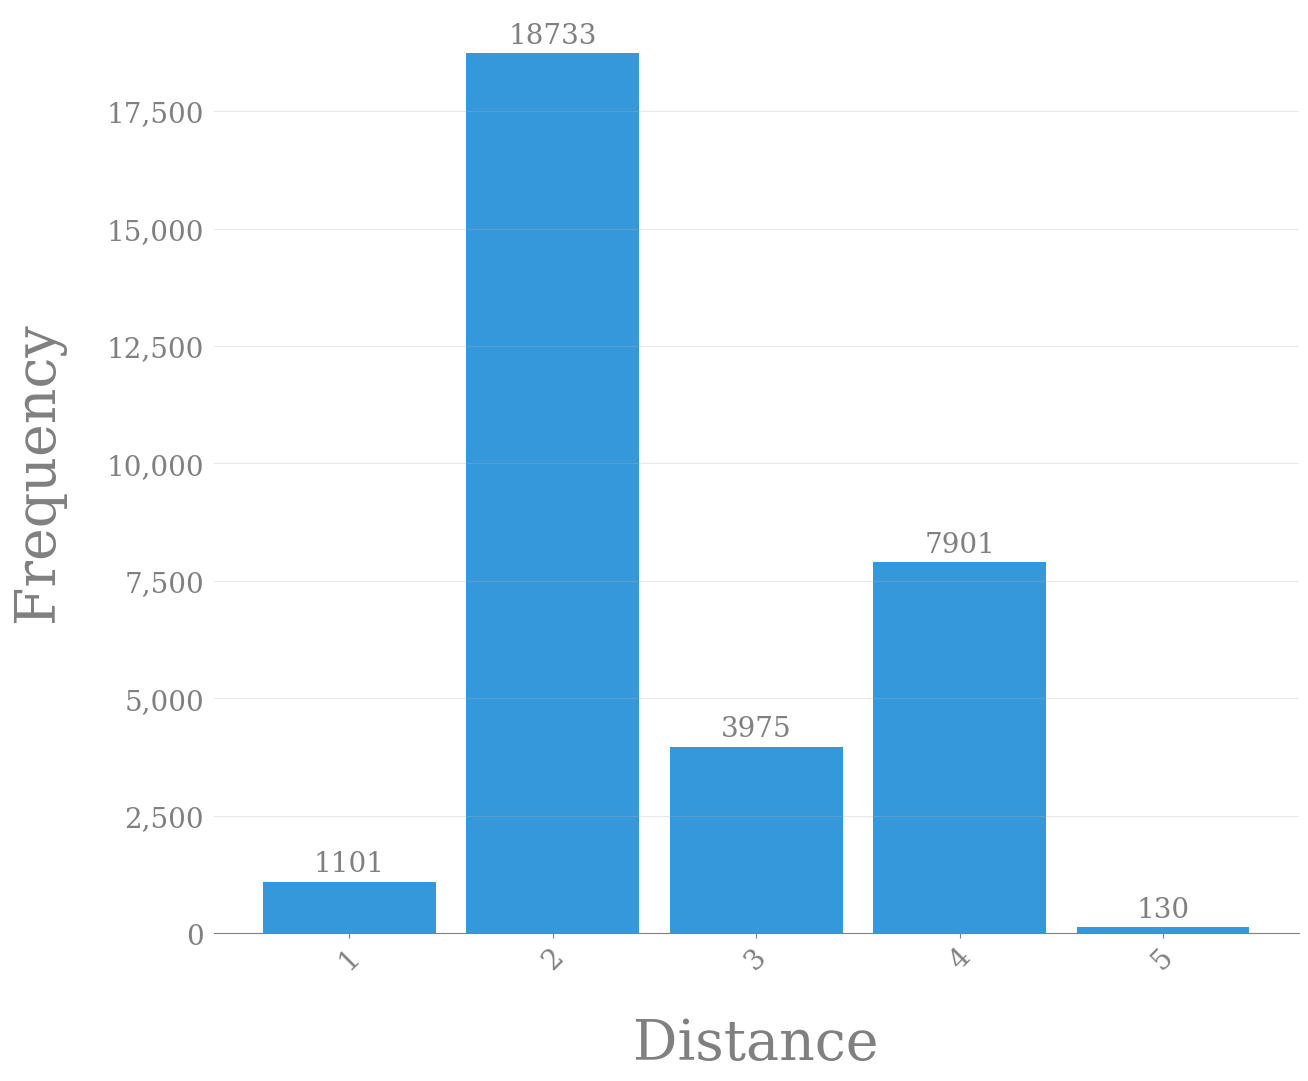

In [46]:
differing_distances_fixed_values = [dist for _, _, dist in differing_distances_fixed]

#Font settings
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
})

#Instantiate plot
fig, ax = plt.subplots(figsize=(14,12))
counts, bins, patches = ax.hist(differing_distances_fixed_values, color = "#3498db", rwidth=0.85, bins = int(max(differing_distances_fixed_values) - min(differing_distances_fixed_values) + 1))

#Format plot
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.grid(axis="y", alpha=0.3, linestyle='-')
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines['bottom'].set_color("grey")
ax.tick_params(axis='x', colors="grey")
ax.xaxis.label.set_color("grey")
ax.yaxis.label.set_color("grey")
ax.set_ylim(bottom=0)
ax.yaxis.set_tick_params(width=0)
plt.xticks(rotation=45)
plt.xticks(fontsize=20, color='grey')
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.xticks(bin_centers)
plt.yticks(fontsize=20, color='grey')
ax.set_xlabel(f"Distance", fontsize=40, color='grey', labelpad = 30)
ax.set_ylabel(f"Frequency", fontsize=40, color='grey', labelpad= 30)
ax.bar_label(patches, fmt='%d', fontsize=20, color='grey', padding=3)

plt.show()

#Create data directory if it doesn't exist
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/histogram_fixed.png", dpi=600, bbox_inches="tight")

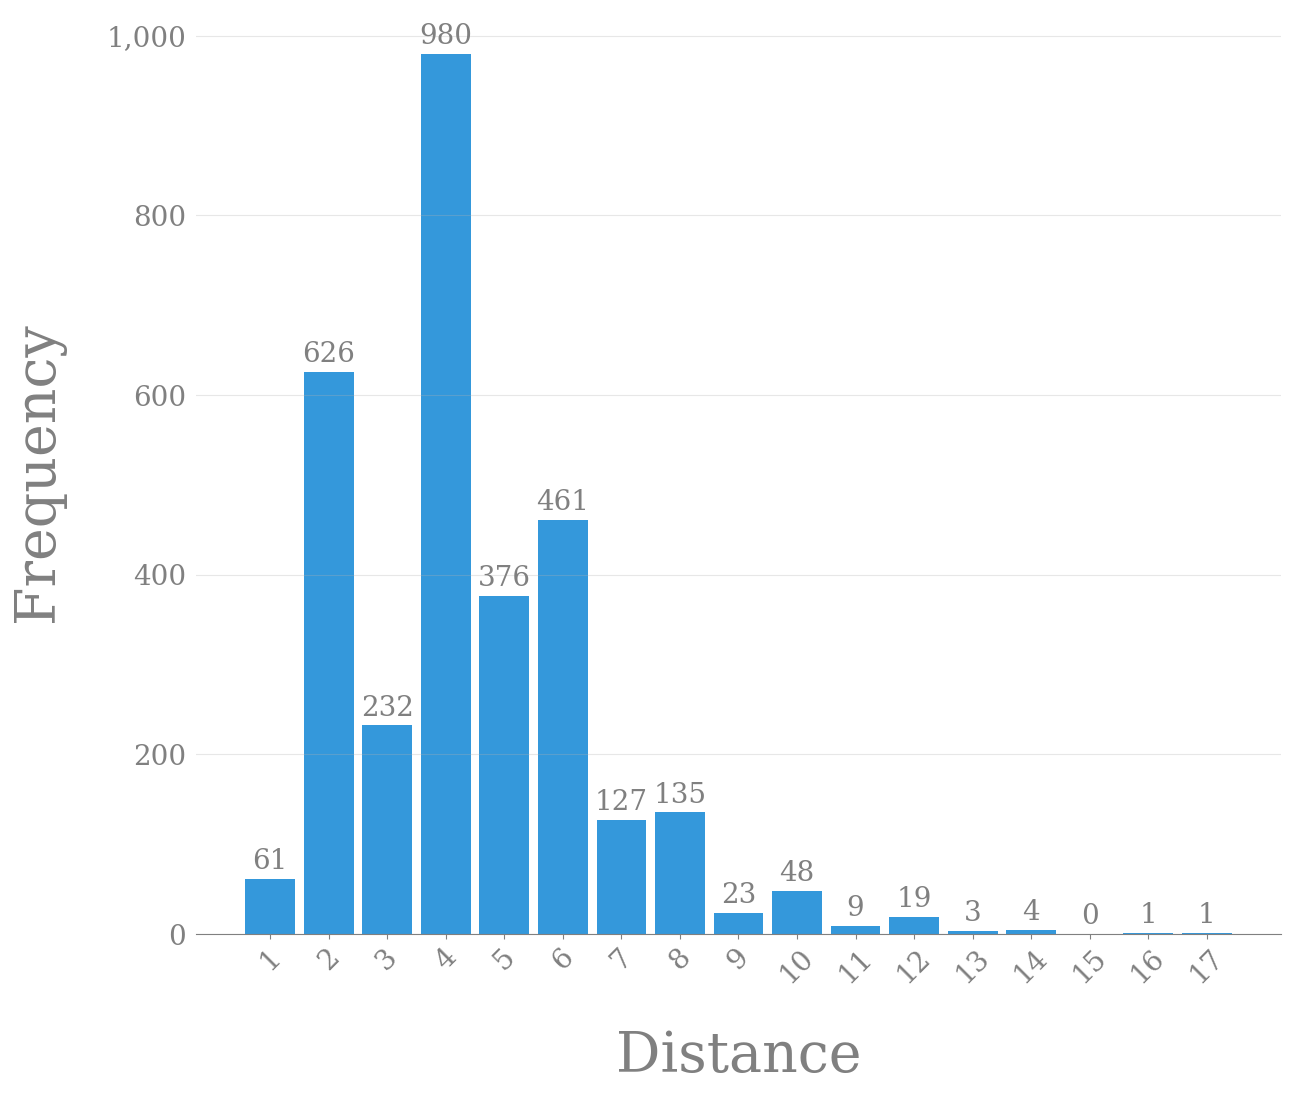

In [47]:
differing_distances_dynamic_values = [dist for _, _, dist in differing_distances_dynamic]

#Font settings
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
})

#Instantiate plot
fig, ax = plt.subplots(figsize=(14,12))
counts, bins, patches = ax.hist(differing_distances_dynamic_values, color = "#3498db", rwidth=0.85, bins = int(max(differing_distances_dynamic_values) - min(differing_distances_dynamic_values) + 1))

#Format plot
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.grid(axis="y", alpha=0.3, linestyle='-')
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines['bottom'].set_color("grey")
ax.tick_params(axis='x', colors="grey")
ax.xaxis.label.set_color("grey")
ax.yaxis.label.set_color("grey")
ax.set_ylim(bottom=0)
ax.yaxis.set_tick_params(width=0)
plt.xticks(rotation=45)
plt.xticks(fontsize=20, color='grey')
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.xticks(bin_centers)
plt.yticks(fontsize=20, color='grey')
ax.set_xlabel(f"Distance", fontsize=40, color='grey', labelpad = 30)
ax.set_ylabel(f"Frequency", fontsize=40, color='grey', labelpad= 30)
ax.bar_label(patches, fmt='%d', fontsize=20, color='grey', padding=3)

plt.show()

#Create data directory if it doesn't exist
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/histogram_dynamic.png", dpi=600, bbox_inches="tight")